# CRC_CMS SpaCross MULTI

Subject-level multi-sample SpaCross benchmark for CRC_CMS_10x. This version saves only `predictions.parquet`, `performance.parquet`, and `benchmark.log`; it does not save CSV files or intermediate latent/reconstruction arrays.


# Imports


In [1]:
# =============================================================================
# Imports
# =============================================================================
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import logging
from pathlib import Path

# Make the kernel robust if launched through VSCode/Jupyter rather than
# from an already activated conda shell.
CONDA_PREFIX = Path(sys.executable).resolve().parents[1]
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["PYTHONNOUSERSITE"] = "1"
os.environ["LD_LIBRARY_PATH"] = (
    f"{CONDA_PREFIX / 'lib'}:" + os.environ.get("LD_LIBRARY_PATH", "")
)

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import torch
import yaml
import scipy.sparse as sp
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_score,
    completeness_score,
    v_measure_score,
)
from scipy.optimize import linear_sum_assignment



# USER CONFIGURATION — edit these to match your environment


In [2]:
# =============================================================================
# USER CONFIGURATION
# =============================================================================

# SpaCross repo root (contains Config/ and SpaCross/ python package).
# The first existing path will be used.
SPACROSS_ROOT_CANDIDATES = [
    Path(r"/home/dal875013/work/projects/mocha/methods/spacross/SpaCross"),
    Path(r"/work/dal875013/projects/mocha/methods/spacross/SpaCross"),
]
SPACROSS_ROOT = next((p for p in SPACROSS_ROOT_CANDIDATES if p.exists()), SPACROSS_ROOT_CANDIDATES[0])

# Path to the folder containing CRC_CMS_10x h5ad files.
DATA_ROOT = Path(r"/groups/qiwei/mocha/QuickSRT/CRC_CMS_10x/data")

# Output folder for subject-level multi-sample SpaCross benchmark.
OUTPUT_DIR = Path(r"/home/dal875013/work/projects/mocha/results/Spacross/crc_cms_spacross_MULTI")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# SpaCross config.
# We keep the existing SpaCross DLPFC.yaml as the base config, then override dataset-specific fields below.
CONFIG_PATH = SPACROSS_ROOT / "Config" / "DLPFC.yaml"

METHOD_NAME = "SpaCross_multi"

# Subject-level CRC_CMS grouping from the README.
CRC_CMS_SUBJECT_GROUPS = {
    "subject_1": ["SN048_A121573_Rep1", "SN048_A121573_Rep2"],
    "subject_2": ["SN048_A416371_Rep1", "SN048_A416371_Rep2"],
    "subject_3": ["SN123_A551763_Rep1", "SN124_A551763_Rep2"],
    "subject_4": ["SN123_A595688_Rep1", "SN124_A595688_Rep2"],
    "subject_5": ["SN123_A798015_Rep1", "SN124_A798015_Rep2"],
    "subject_6": ["SN123_A938797_Rep1_X", "SN124_A938797_Rep2"],
    "subject_7": ["SN84_A120838_Rep1", "SN84_A120838_Rep2"],
}

# ----- SUBSET SELECTOR -----------------------------------------------------
# Set SUBJECT_GROUPS_TO_RUN to:
#   - None or "all" -> run all subject groups
#   - a list like ["subject_1", "subject_2"] -> run selected subject groups
#   - a single string "subject_3" -> run just that subject
SUBJECT_GROUPS_TO_RUN = "all"

# Number of runs per subject group.
NUM_RUNS = 1

# Fixed spatial domains for CRC_CMS multi-sample benchmark.
NUM_CLUSTERS_CRC_CMS = 6

# Clustering algorithm used on the SpaCross subject-level latent representation.
CLUST_METHOD = "mclust"

# Ground-truth label columns to try, in order.
GT_LABEL_COL_CANDIDATES = ["z", "layer_guess", "Ground Truth", "ground_truth", "manual_layer", "label"]

# Spatial coordinate keys.
SPATIAL_KEY = "spatial"
RAW_SPATIAL_KEYS = ["S", "spatial"]

# SpaCross multi-sample graph / alignment settings.
USE_ALIGNMENT = True
ALIGN_METHOD = "icp"
ALIGN_DATA_TYPE = "auto"       # "auto", "Visium", or "ST"
ALIGN_PLOT = False
ALIGNED_SPATIAL_KEY = "spatial_aligned"

GRAPH_MODE = "KNN"
SLICE_DIST_MICRON = None       # keep None by default; edit if needed
C2C_DIST = 100

# Preprocessing settings.
COUNT_LAYER = "count"
N_TOP_GENES = 2000
MIN_GENE_CELLS = 50
MIN_GENE_COUNTS = 10
NORMALIZE_TARGET_SUM = 1e6
PCA_N_COMPONENTS = 200

# Output keys.
LATENT_KEY = "latent"
RECON_KEY = "recon"
CLUSTER_KEY = "spacross_multi"

BASE_SEED = 3407


# GPU / device, logging, and helpers


In [3]:
# =============================================================================
# GPU / device setup
# =============================================================================
def get_device():
    """Return 'cuda:0' if a CUDA GPU is available, else 'cpu'. Logs details."""
    if torch.cuda.is_available():
        dev = "cuda:0"
        os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
        logging.info(f"[DEVICE] CUDA available -- using {dev}")
        logging.info(f"[DEVICE] GPU name: {torch.cuda.get_device_name(0)}")
        logging.info(
            f"[DEVICE] GPU memory: "
            f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB"
        )
    else:
        dev = "cpu"
        logging.warning("[DEVICE] No CUDA GPU -- falling back to CPU")
    return dev


# =============================================================================
# Logging setup
# =============================================================================
def setup_logging(output_dir: Path):
    output_dir.mkdir(parents=True, exist_ok=True)
    log_file = output_dir / "benchmark.log"
    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s [%(levelname)s] %(message)s",
        handlers=[
            logging.StreamHandler(sys.stdout),
            logging.FileHandler(log_file, mode="w", encoding="utf-8"),
        ],
        force=True,
    )
    logging.info(f"Log file: {log_file}")


# =============================================================================
# Helpers
# =============================================================================
def resolve_subject_groups(selector):
    """Turn SUBJECT_GROUPS_TO_RUN into a concrete subject_name -> sample_ids dict."""
    if selector is None or selector == "all":
        return dict(CRC_CMS_SUBJECT_GROUPS)
    if isinstance(selector, str):
        if selector not in CRC_CMS_SUBJECT_GROUPS:
            raise KeyError(f"Unknown subject group: {selector}. Available: {list(CRC_CMS_SUBJECT_GROUPS)}")
        return {selector: CRC_CMS_SUBJECT_GROUPS[selector]}
    if isinstance(selector, (list, tuple)):
        out = {}
        for name in selector:
            if name not in CRC_CMS_SUBJECT_GROUPS:
                raise KeyError(f"Unknown subject group: {name}. Available: {list(CRC_CMS_SUBJECT_GROUPS)}")
            out[name] = CRC_CMS_SUBJECT_GROUPS[name]
        return out
    raise ValueError(f"Unrecognized SUBJECT_GROUPS_TO_RUN value: {selector!r}")


def _copy_matrix(X):
    """Robust matrix copy that preserves sparse matrices when possible."""
    if sp.issparse(X):
        return X.copy()
    if hasattr(X, "copy"):
        return X.copy()
    return np.asarray(X).copy()


def detect_gt_column(adata):
    """Detect the ground-truth label column in adata.obs."""
    for col in GT_LABEL_COL_CANDIDATES:
        if col in adata.obs.columns:
            return col
    raise KeyError(
        "No ground-truth column found. "
        f"Tried {GT_LABEL_COL_CANDIDATES}; available obs columns: {list(adata.obs.columns)}"
    )


def infer_alignment_data_type(adata_list):
    """
    Decide whether SpaCross align_spots should use Visium mode or ST mode.
    Visium mode requires obs['array_row'] and obs['array_col']; our QuickSRT h5ad
    files often only provide obsm['S'], so ST mode is the safe fallback.
    """
    if ALIGN_DATA_TYPE != "auto":
        return ALIGN_DATA_TYPE

    has_visium_cols = all(
        ("array_row" in a.obs.columns and "array_col" in a.obs.columns)
        for a in adata_list
    )
    return "Visium" if has_visium_cols else "ST"


def sparse_mx_to_torch_sparse_tensor(sparse_mx):
    """Convert a scipy sparse matrix to a torch sparse tensor."""
    sparse_mx = sparse_mx.tocoo().astype(np.float32)
    indices = torch.from_numpy(np.vstack((sparse_mx.row, sparse_mx.col)).astype(np.int64))
    values = torch.from_numpy(sparse_mx.data)
    shape = torch.Size(sparse_mx.shape)
    return torch.sparse.FloatTensor(indices, values, shape)



# Data loading and SpaCross 3D graph construction


In [4]:
# =============================================================================
# Data loading  (adapted for .h5ad input)
# =============================================================================
def load_one_crc_cms_slice_for_spacross(sample_id: str):
    """
    Load one CRC_CMS .h5ad slice and convert it into the common benchmark format.

    This follows the storage style of the attached multi-sample benchmark:
      - read SCE_<sample>.h5ad from DATA_ROOT
      - use obs['z'] or another detected column as ground truth
      - alias obsm['S'] -> obsm['spatial'] if needed
      - preserve original spot IDs for prediction parquet / visualization
      - make obs_names unique across slices
    """
    h5ad_path = DATA_ROOT / f"SCE_{sample_id}.h5ad"
    logging.info(f"    [LOAD] Reading {h5ad_path}")

    if not h5ad_path.exists():
        raise FileNotFoundError(f"Missing .h5ad file: {h5ad_path}")

    adata = sc.read_h5ad(h5ad_path)
    adata.var_names_make_unique()

    logging.info(
        f"    [DIAG] {sample_id}: n_obs={adata.n_obs}, n_vars={adata.n_vars}"
    )
    logging.info(f"    [DIAG] {sample_id}: obs columns={list(adata.obs.columns)}")
    logging.info(f"    [DIAG] {sample_id}: obsm keys={list(adata.obsm.keys())}")

    # ---- Ground-truth label column ----
    gt_col = detect_gt_column(adata)
    adata.obs["layer_guess"] = adata.obs[gt_col].astype(object)
    adata.obs["sample"] = sample_id
    adata.obs["original_spot_id"] = adata.obs_names.astype(str)

    n_labeled = int(adata.obs["layer_guess"].notna().sum())
    uniq = sorted([str(x) for x in adata.obs["layer_guess"].dropna().unique()])
    logging.info(
        f"    [DIAG] {sample_id}: using GT column '{gt_col}' "
        f"(labeled spots: {n_labeled}/{adata.n_obs}, classes={uniq})"
    )

    # ---- Spatial coordinates ----
    if SPATIAL_KEY not in adata.obsm:
        found_key = None
        for key in RAW_SPATIAL_KEYS:
            if key in adata.obsm:
                found_key = key
                break

        if found_key is None:
            raise KeyError(
                f"No spatial coordinates found in {h5ad_path}. "
                f"Available obsm keys: {list(adata.obsm.keys())}"
            )

        adata.obsm[SPATIAL_KEY] = np.asarray(adata.obsm[found_key])
        logging.info(f"    [DIAG] {sample_id}: aliased obsm['{found_key}'] -> obsm['{SPATIAL_KEY}']")
    else:
        adata.obsm[SPATIAL_KEY] = np.asarray(adata.obsm[SPATIAL_KEY])

    logging.info(
        f"    [DIAG] {sample_id}: spatial coords shape={adata.obsm[SPATIAL_KEY].shape}"
    )

    # Make obs_names unique across slices, while preserving original_spot_id.
    adata.obs_names = [f"{x}_{sample_id}" for x in adata.obs_names.astype(str)]

    return adata, gt_col


def custom_graph_construction3d_fallback(adata_list, sample_ids, k_cutoff=12):
    """
    Fallback 3D graph construction if the repo's graph_construction3D fails.
    This follows the same high-level idea: combine aligned x/y coordinates with
    an artificial z-axis by slice order, then build a KNN graph in 3D.

    The primary path remains SpaCross.graph_construction3D.
    """
    logging.warning("  [GRAPH] Using custom fallback 3D KNN graph construction.")

    adata_multi = ad.concat(
        adata_list,
        axis=0,
        join="inner",
        merge="same",
        label="slice_name",
        keys=sample_ids,
        index_unique=None,
    )
    adata_multi.obs_names_make_unique()

    # Estimate a reasonable z-step from the median nearest-neighbor distance
    # in the first slice.
    xy0 = np.asarray(adata_list[0].obsm[ALIGNED_SPATIAL_KEY])
    nn0 = NearestNeighbors(n_neighbors=2).fit(xy0)
    d0, _ = nn0.kneighbors(xy0)
    z_step = float(np.median(d0[:, 1]))
    if not np.isfinite(z_step) or z_step <= 0:
        z_step = 1.0

    loc_parts = []
    for slice_idx, a in enumerate(adata_list):
        xy = np.asarray(a.obsm[ALIGNED_SPATIAL_KEY])
        z = np.full((a.n_obs, 1), slice_idx * z_step, dtype=float)
        loc_parts.append(np.concatenate([xy, z], axis=1))

    loc = np.vstack(loc_parts)
    adata_multi.obsm["loc"] = loc

    nbrs = NearestNeighbors(n_neighbors=k_cutoff + 1).fit(loc)
    distances, indices = nbrs.kneighbors(loc)

    rows = []
    cols = []
    for i in range(indices.shape[0]):
        for j in indices[i, 1:]:
            rows.append(i)
            cols.append(int(j))

    adj = sp.coo_matrix(
        (np.ones(len(rows), dtype=np.float32), (rows, cols)),
        shape=(adata_multi.n_obs, adata_multi.n_obs),
    )
    adj = adj + adj.T
    adj.data[:] = 1.0
    adj.eliminate_zeros()

    edge_index = sparse_mx_to_torch_sparse_tensor(adj)
    logging.info(
        f"  [GRAPH] fallback graph: shape={tuple(edge_index.shape)}, "
        f"edges={edge_index._nnz()}"
    )
    return adata_multi, edge_index


def load_crc_cms_subject_group_for_spacross(subject_name: str, sample_ids: list, tools_mod, config: dict):
    """
    Load one subject group, align slices, build the SpaCross 3D graph, and
    globally preprocess the concatenated multi-slice AnnData.

    This is the SpaCross multi-slice counterpart to the attached subject-level
    CellCharter data-loading style.
    """
    logging.info(f"  [SUBJECT] Loading {subject_name}: {sample_ids}")

    adata_list = []
    gt_cols = {}

    for sample_id in sample_ids:
        adata, gt_col = load_one_crc_cms_slice_for_spacross(sample_id)
        adata_list.append(adata)
        gt_cols[sample_id] = gt_col

    # ---------------------------------------------------------------------
    # 1) Align spatial coordinates across slices.
    # ---------------------------------------------------------------------
    if USE_ALIGNMENT:
        alignment_data_type = infer_alignment_data_type(adata_list)
        logging.info(
            f"  [ALIGN] SpaCross.align_spots(method={ALIGN_METHOD!r}, "
            f"data_type={alignment_data_type!r}, coor_key={SPATIAL_KEY!r})"
        )
        try:
            adata_list = tools_mod.align_spots(
                adata_list,
                method=ALIGN_METHOD,
                data_type=alignment_data_type,
                coor_key=SPATIAL_KEY,
                plot=ALIGN_PLOT,
            )
        except Exception as e:
            logging.warning(
                f"  [ALIGN] align_spots failed; using unaligned spatial coordinates. Error: {e}"
            )
            for a in adata_list:
                a.obsm[ALIGNED_SPATIAL_KEY] = np.asarray(a.obsm[SPATIAL_KEY])
    else:
        logging.info("  [ALIGN] Skipping alignment; using obsm['spatial'] as spatial_aligned.")
        for a in adata_list:
            a.obsm[ALIGNED_SPATIAL_KEY] = np.asarray(a.obsm[SPATIAL_KEY])

    # Ensure aligned coordinate key exists.
    for sample_id, a in zip(sample_ids, adata_list):
        if ALIGNED_SPATIAL_KEY not in a.obsm:
            a.obsm[ALIGNED_SPATIAL_KEY] = np.asarray(a.obsm[SPATIAL_KEY])
        logging.info(
            f"  [DIAG] {sample_id}: {ALIGNED_SPATIAL_KEY} shape="
            f"{a.obsm[ALIGNED_SPATIAL_KEY].shape}"
        )

    # ---------------------------------------------------------------------
    # 2) Build SpaCross multi-slice 3D graph.
    # ---------------------------------------------------------------------
    logging.info("  [GRAPH] Building SpaCross 3D KNN graph with graph_construction3D")
    try:
        adata_multi, edge_index = tools_mod.graph_construction3D(
            adata_list,
            section_ids=sample_ids,
            coor_key=ALIGNED_SPATIAL_KEY,
            k_cutoff=config["data"]["k_cutoff"],
            slice_dist_micron=SLICE_DIST_MICRON,
            c2c_dist=C2C_DIST,
            mode=GRAPH_MODE,
            norm=False,
        )
    except Exception as e:
        logging.warning(f"  [GRAPH] SpaCross graph_construction3D failed. Error: {e}")
        adata_multi, edge_index = custom_graph_construction3d_fallback(
            adata_list,
            sample_ids=sample_ids,
            k_cutoff=config["data"]["k_cutoff"],
        )

    # Required by SC_BC_pipeline.
    sample_to_slice_id = {s: i for i, s in enumerate(sample_ids)}
    if "sample" not in adata_multi.obs.columns:
        adata_multi.obs["sample"] = adata_multi.obs["slice_name"].astype(str)
    adata_multi.obs["sample"] = adata_multi.obs["sample"].astype(str)
    adata_multi.obs["slice_id"] = adata_multi.obs["sample"].map(sample_to_slice_id).astype(int)

    # Keep original spatial for metrics/plotting if needed.
    if SPATIAL_KEY not in adata_multi.obsm and ALIGNED_SPATIAL_KEY in adata_multi.obsm:
        adata_multi.obsm[SPATIAL_KEY] = np.asarray(adata_multi.obsm[ALIGNED_SPATIAL_KEY])

    logging.info(
        f"  [DIAG] Combined {subject_name}: n_obs={adata_multi.n_obs}, "
        f"n_vars={adata_multi.n_vars}, slices={sample_ids}"
    )
    if isinstance(edge_index, torch.Tensor):
        logging.info(
            f"  [DIAG] edge_index/adj shape={tuple(edge_index.shape)}, "
            f"is_sparse={edge_index.is_sparse}"
        )

    # ---------------------------------------------------------------------
    # 3) Global SpaCross-style preprocessing on the combined subject AnnData.
    #    Node count must remain unchanged after graph construction, so only
    #    filter/select genes, not cells/spots.
    # ---------------------------------------------------------------------
    adata_multi.layers[COUNT_LAYER] = _copy_matrix(adata_multi.X)

    sc.pp.filter_genes(adata_multi, min_cells=MIN_GENE_CELLS)
    sc.pp.filter_genes(adata_multi, min_counts=MIN_GENE_COUNTS)
    logging.info(f"  [DIAG] After gene filtering: n_vars={adata_multi.n_vars}")

    sc.pp.normalize_total(adata_multi, target_sum=NORMALIZE_TARGET_SUM)

    n_top = min(int(config["data"].get("top_genes", N_TOP_GENES)), adata_multi.n_vars)
    sc.pp.highly_variable_genes(
        adata_multi,
        flavor="seurat_v3",
        layer=COUNT_LAYER,
        n_top_genes=n_top,
    )

    adata_multi = adata_multi[:, adata_multi.var["highly_variable"]].copy()
    logging.info(
        f"  [DIAG] After HVG selection: n_vars={adata_multi.n_vars} "
        f"(target={n_top})"
    )

    sc.pp.scale(adata_multi)

    n_pcs = min(PCA_N_COMPONENTS, adata_multi.n_vars, adata_multi.n_obs - 1)
    adata_multi.obsm["X_pca"] = PCA(
        n_components=n_pcs,
        random_state=BASE_SEED,
    ).fit_transform(adata_multi.X).astype(np.float32)

    logging.info(f"  [DIAG] PCA done: X_pca shape={adata_multi.obsm['X_pca'].shape}")

    return adata_multi, edge_index, gt_cols



# Metrics helpers


In [5]:
# =============================================================================
# Metrics helpers
# =============================================================================
def clustering_accuracy(y_true, y_pred):
    """
    Clustering accuracy after optimal label matching via Hungarian algorithm.
    This is useful as a simple ACC column comparable across unsupervised runs.
    """
    y_true = pd.Series(y_true).astype(str).to_numpy()
    y_pred = pd.Series(y_pred).astype(str).to_numpy()

    true_classes = pd.Index(sorted(pd.unique(y_true)))
    pred_classes = pd.Index(sorted(pd.unique(y_pred)))

    contingency = np.zeros((len(true_classes), len(pred_classes)), dtype=np.int64)
    true_map = {c: i for i, c in enumerate(true_classes)}
    pred_map = {c: j for j, c in enumerate(pred_classes)}

    for t, p in zip(y_true, y_pred):
        contingency[true_map[t], pred_map[p]] += 1

    row_ind, col_ind = linear_sum_assignment(-contingency)
    return float(contingency[row_ind, col_ind].sum() / contingency.sum())


def compute_metrics_for_slice(adata_slice, label_key="layer_guess", pred_key=CLUSTER_KEY):
    """Compute metrics on labeled spots only for one slice."""
    labeled_mask = adata_slice.obs[label_key].notna()
    sub = adata_slice[labeled_mask].copy()

    if sub.n_obs == 0:
        return {
            "ARI": np.nan,
            "NMI": np.nan,
            "ACC": np.nan,
            "HOM": np.nan,
            "COM": np.nan,
            "V_measure": np.nan,
        }, sub

    y_true = sub.obs[label_key].astype(str).to_numpy()
    y_pred = sub.obs[pred_key].astype(str).to_numpy()

    metric_vals = {
        "ARI": float(adjusted_rand_score(y_true, y_pred)),
        "NMI": float(normalized_mutual_info_score(y_true, y_pred)),
        "ACC": float(clustering_accuracy(y_true, y_pred)),
        "HOM": float(homogeneity_score(y_true, y_pred)),
        "COM": float(completeness_score(y_true, y_pred)),
        "V_measure": float(v_measure_score(y_true, y_pred)),
    }
    return metric_vals, sub



# Subject-level SpaCross multi-slice training


In [6]:
# =============================================================================
# Train one subject group and return slice-level metrics
# =============================================================================
def train_one_subject_group(
    subject_name: str,
    sample_ids: list,
    adata,
    edge_index,
    config: dict,
    device: str,
    tools_mod,
    run_seed: int = 0,
):
    """
    Run SpaCross multi-slice training once on one subject group, then compute
    metrics separately for each slice.

    Method body follows the official SpaCross multi-slice idea:
        aligned coordinates
        -> graph_construction3D
        -> SC_BC_pipeline with obs['slice_id']
        -> subject-level latent representation
        -> subject-level mclust/kmeans clustering
        -> slice-level metrics/output
    """
    num_clusters = int(NUM_CLUSTERS_CRC_CMS)

    logging.info(
        f"  [TRAIN] Starting SpaCross multi-slice | subject={subject_name} | "
        f"slices={sample_ids} | k_clusters={num_clusters} | "
        f"device={device} | run_seed={run_seed}"
    )

    seed = BASE_SEED + run_seed
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    t0 = time.time()

    net = tools_mod.SC_BC_pipeline(
        adata,
        edge_index=edge_index,
        num_clusters=num_clusters,
        device=device,
        config=config,
        roundseed=run_seed,
        imputation=False,
    )

    net.trian()
    enc_rep, recon = net.process()

    adata.obsm[LATENT_KEY] = enc_rep
    adata.obsm[RECON_KEY] = recon

    logging.info(
        f"  [DIAG] subject={subject_name}: latent shape={enc_rep.shape}, "
        f"recon shape={recon.shape}"
    )

    # Subject-level clustering on the integrated SpaCross latent representation.
    pred_labels = tools_mod.clustering(
        z=enc_rep,
        n_clust=num_clusters,
        num_seed=1,
        method=CLUST_METHOD,
    )

    adata.obs[CLUSTER_KEY] = pd.Categorical(
        pd.Series(pred_labels, index=adata.obs_names).astype(str)
    )

    logging.info(
        f"  [DIAG] {subject_name}: cluster sizes="
        f"{adata.obs[CLUSTER_KEY].astype(str).value_counts().to_dict()}"
    )


    elapsed = time.time() - t0
    gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

    metrics_list = []
    pred_frames = []

    # ---------------------------------------------------------------------
    # Slice-level metrics and predictions.
    # ---------------------------------------------------------------------
    for sample_id in sample_ids:
        mask = adata.obs["sample"].astype(str).to_numpy() == str(sample_id)
        slice_adata = adata[mask].copy()

        metric_vals, labeled_slice = compute_metrics_for_slice(
            slice_adata,
            label_key="layer_guess",
            pred_key=CLUSTER_KEY,
        )

        metrics = {
            "method": METHOD_NAME,
            "training_unit": subject_name,
            "sample": sample_id,
            "training_samples": ",".join(sample_ids),
            "run_seed": run_seed,
            **metric_vals,
            # Keep DIS column for compatibility with older SpaCross-style summaries.
            "DIS": np.nan,
            # Allocate subject-level runtime across slices for table compatibility.
            "running_time_sec": round(elapsed / max(1, len(sample_ids)), 2),
            "subject_running_time_sec": round(elapsed, 2),
            "unit_running_time_sec": round(elapsed, 2),
            "gpu_model": gpu_name,
            "num_clusters": int(num_clusters),
            "num_spots": int(slice_adata.n_obs),
            "num_labeled_spots": int(labeled_slice.n_obs),
            "num_training_spots": int(adata.n_obs),
            "num_genes_after_hvg": int(adata.n_vars),
            "pca_dim": int(adata.obsm["X_pca"].shape[1]),
            "latent_dim": int(enc_rep.shape[1]),
            "k_cutoff": int(config["data"]["k_cutoff"]),
            "topk_neighs": int(config["train"]["topk_neighs"]),
            "topk_neighs_inter": int(config["train"]["topk_neighs_inter"]),
            "cluster_key": CLUSTER_KEY,
            "clust_method": CLUST_METHOD,
            "device": device,
        }
        metrics_list.append(metrics)

        logging.info(
            f"  [METRICS] {subject_name}/{sample_id}: "
            f"ARI={metric_vals['ARI']:.4f}  NMI={metric_vals['NMI']:.4f}  "
            f"ACC={metric_vals['ACC']:.4f}  "
            f"allocated_time={elapsed / len(sample_ids):.1f}s  "
            f"subject_time={elapsed:.1f}s  gpu={gpu_name}"
        )

        spot_ids = (
            slice_adata.obs["original_spot_id"].astype(str).to_numpy()
            if "original_spot_id" in slice_adata.obs.columns
            else slice_adata.obs_names.astype(str).to_numpy()
        )

        pred_frames.append(
            pd.DataFrame(
                {
                    "method": METHOD_NAME,
                    "training_unit": subject_name,
                    "sample": sample_id,
                    "run_seed": run_seed,
                    "spot_id": spot_ids,
                    "true_label": slice_adata.obs["layer_guess"].astype(object).to_numpy(),
                    "pred_label": slice_adata.obs[CLUSTER_KEY].astype(str).to_numpy(),
                }
            )
        )

    pred_df = pd.concat(pred_frames, ignore_index=True)

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return metrics_list, pred_df



# Main benchmark loop


In [7]:
# =============================================================================
# Main benchmark loop
# =============================================================================
def run_benchmark():
    setup_logging(OUTPUT_DIR)

    logging.info("=" * 72)
    logging.info("SpaCross CRC_CMS Subject-Level Multi-Sample Benchmarking Framework")
    logging.info("=" * 72)

    # Register SpaCross package.
    if not SPACROSS_ROOT.exists():
        raise FileNotFoundError(
            f"SPACROSS_ROOT not found: {SPACROSS_ROOT.resolve()}\n"
            f"Clone it with: git clone https://github.com/wenwenmin/SpaCross.git"
        )

    if str(SPACROSS_ROOT.resolve()) not in sys.path:
        sys.path.insert(0, str(SPACROSS_ROOT.resolve()))

    import SpaCross as TOOLS

    if not DATA_ROOT.exists():
        raise FileNotFoundError(f"DATA_ROOT not found: {DATA_ROOT.resolve()}")

    device = get_device()

    logging.info(f"[PATHS] SPACROSS_ROOT = {SPACROSS_ROOT.resolve()}")
    logging.info(f"[PATHS] DATA_ROOT     = {DATA_ROOT.resolve()}")
    logging.info(f"[PATHS] OUTPUT_DIR    = {OUTPUT_DIR.resolve()}")
    logging.info(f"[PATHS] CONFIG_PATH   = {CONFIG_PATH.resolve()}")
    logging.info(f"[ENV] Python          = {sys.executable}")
    logging.info(f"[VERSIONS] scanpy     = {sc.__version__}")
    logging.info(f"[VERSIONS] torch      = {torch.__version__}")
    logging.info(f"[VERSIONS] SpaCross   = {getattr(TOOLS, '__version__', TOOLS.__file__)}")

    with open(CONFIG_PATH, "r", encoding="utf-8") as f:
        config = yaml.safe_load(f)

    # Multi-slice SpaCross needs topk_neighs_inter for SC_BC_pipeline.
    config["data"]["dataset"] = "CRC_CMS_MULTI"
    config["data"]["k_cutoff"] = int(config["data"].get("k_cutoff", 12))
    config["data"]["top_genes"] = int(config["data"].get("top_genes", N_TOP_GENES))
    config["train"]["topk_neighs"] = int(config["train"].get("topk_neighs", 20))
    config["train"]["topk_neighs_inter"] = int(config["train"].get("topk_neighs_inter", 30))

    logging.info(f"[CONFIG] {config}")

    subject_groups = resolve_subject_groups(SUBJECT_GROUPS_TO_RUN)
    logging.info(f"[SUBJECTS] Will process {len(subject_groups)} subject group(s): {subject_groups}")
    logging.info(
        f"[SETTINGS] NUM_RUNS={NUM_RUNS} | K={NUM_CLUSTERS_CRC_CMS} | "
        f"CLUST_METHOD={CLUST_METHOD} | USE_ALIGNMENT={USE_ALIGNMENT}"
    )
    logging.info("[MODE] subject-level joint SpaCross multi-slice training; slice-level metrics/output")

    all_metrics = []
    all_predictions = []
    failed = []

    for i, (subject_name, sample_ids) in enumerate(subject_groups.items(), start=1):
        logging.info("")
        logging.info("-" * 72)
        logging.info(f"[{i}/{len(subject_groups)}] Subject group {subject_name}: {sample_ids}")
        logging.info("-" * 72)

        try:
            for run in range(NUM_RUNS):
                logging.info(f"  -> Run {run + 1}/{NUM_RUNS}")

                # Reload data for each run because SpaCross modifies AnnData.
                adata, edge_index, gt_cols = load_crc_cms_subject_group_for_spacross(
                    subject_name=subject_name,
                    sample_ids=sample_ids,
                    tools_mod=TOOLS,
                    config=config,
                )

                metrics_list, pred_df = train_one_subject_group(
                    subject_name=subject_name,
                    sample_ids=sample_ids,
                    adata=adata,
                    edge_index=edge_index,
                    config=config,
                    device=device,
                    tools_mod=TOOLS,
                    run_seed=run,
                )

                for row in metrics_list:
                    row["gt_col"] = gt_cols.get(row["sample"], "layer_guess")
                all_metrics.extend(metrics_list)
                all_predictions.append(pred_df)

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        except Exception as e:
            logging.exception(f"[FAILED] Subject group {subject_name}: {e}")
            failed.append({"training_unit": subject_name, "error": str(e)})
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            continue

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    if not all_metrics:
        logging.error("No successful runs — nothing to save.")
        return pd.DataFrame(), pd.DataFrame(), failed

    predictions = pd.concat(all_predictions, ignore_index=True)
    performance = pd.DataFrame(all_metrics)

    perf_lead = [
        "method", "training_unit", "sample", "run_seed",
        "ARI", "NMI", "ACC", "DIS", "HOM", "COM", "V_measure",
        "running_time_sec", "subject_running_time_sec", "unit_running_time_sec",
        "gpu_model", "training_samples",
    ]
    performance = performance[
        perf_lead + [c for c in performance.columns if c not in perf_lead]
    ]

    pred_lead = ["method", "training_unit", "sample", "run_seed", "spot_id", "true_label", "pred_label"]
    predictions = predictions[pred_lead]

    pred_path = OUTPUT_DIR / "predictions.parquet"
    perf_path = OUTPUT_DIR / "performance.parquet"

    predictions.to_parquet(pred_path, index=False)
    performance.to_parquet(perf_path, index=False)


    logging.info("")
    logging.info("=" * 72)
    logging.info("SAVED")
    logging.info("=" * 72)
    logging.info(f"  predictions.parquet -> {pred_path}  ({len(predictions):,} rows)")
    logging.info(f"  performance.parquet -> {perf_path}  ({len(performance):,} rows)")

    logging.info("")
    logging.info("Per-slice metrics:")
    show_cols = [
        "training_unit", "sample", "ARI", "NMI", "ACC",
        "HOM", "COM", "V_measure",
        "running_time_sec", "subject_running_time_sec",
    ]
    show_cols = [c for c in show_cols if c in performance.columns]
    logging.info("\n" + performance[show_cols].to_string(index=False))

    logging.info("")
    logging.info(
        f"Overall mean ARI: {performance['ARI'].mean():.4f}  "
        f"NMI: {performance['NMI'].mean():.4f}  "
        f"ACC: {performance['ACC'].mean():.4f}"
    )
    logging.info(f"GPU model(s) used: {sorted(performance['gpu_model'].unique().tolist())}")
    logging.info(
        "Total subject-level running time: "
        f"{performance[['training_unit', 'run_seed', 'subject_running_time_sec']].drop_duplicates()['subject_running_time_sec'].sum():.1f}s"
    )

    if failed:
        logging.warning(f"{len(failed)} subject group(s) failed. See benchmark.log for details.")
    else:
        logging.info("[DONE] All requested subject groups completed successfully.")

    return performance, predictions, failed


# Execute the benchmark when this cell is run.
performance, predictions, failed = run_benchmark()



2026-05-18 03:27:28,493 [INFO] Log file: /home/dal875013/work/projects/mocha/results/Spacross/crc_cms_spacross_MULTI/benchmark.log
2026-05-18 03:27:28,494 [INFO] ========================================================================
2026-05-18 03:27:28,495 [INFO] SpaCross CRC_CMS Subject-Level Multi-Sample Benchmarking Framework
2026-05-18 03:27:28,495 [INFO] ========================================================================
2026-05-18 03:27:30,419 [INFO] cffi mode is CFFI_MODE.ANY
2026-05-18 03:27:30,495 [INFO] R home found: /work/dal875013/conda_envs/spacross_env/lib/R
2026-05-18 03:27:31,069 [INFO] R library path: /work/dal875013/conda_envs/spacross_env/lib:/work/dal875013/conda_envs/spacross_env/lib:
2026-05-18 03:27:31,070 [INFO] LD_LIBRARY_PATH: /work/dal875013/conda_envs/spacross_env/lib:/work/dal875013/conda_envs/spacross_env/lib
2026-05-18 03:27:31,076 [INFO] Default options to initialize R: rpy2, --quiet, --no-save
2026-05-18 03:27:31,448 [INFO] R is already initializ

Epoch 299 total loss=1.416 recon loss=0.777 mean loss=0.429 tri loss=1.369: 100%|██████████| 300/300 [00:06<00:00, 49.35it/s]

2026-05-18 03:27:47,934 [INFO]   [DIAG] subject=subject_1: latent shape=(4343, 16), recon shape=(4343, 200)


[DEBUG mclust] emb shape = (4343, 16), dtype = float64
fitting ...
  |======================================================================| 100%
2026-05-18 03:27:54,843 [INFO]   [DIAG] subject_1: cluster sizes={'2': 1489, '4': 830, '1': 747, '6': 675, '3': 357, '5': 245}
2026-05-18 03:27:54,900 [INFO]   [METRICS] subject_1/SN048_A121573_Rep1: ARI=0.2358  NMI=0.3216  ACC=0.4045  allocated_time=6.6s  subject_time=13.2s  gpu=NVIDIA A30
2026-05-18 03:27:54,964 [INFO]   [METRICS] subject_1/SN048_A121573_Rep2: ARI=0.2430  NMI=0.3156  ACC=0.4160  allocated_time=6.6s  subject_time=13.2s  gpu=NVIDIA A30
2026-05-18 03:27:54,969 [INFO] 
2026-05-18 03:27:54,970 [INFO] ------------------------------------------------------------------------
2026-05-18 03:27:54,970 [INFO] [2/7] Subject group subject_2: ['SN048_A416371_Rep1', 'SN048_A416371_Rep2']
2026-05-18 03:27:54,971 [INFO] ------------------------------------------------------------------------
2026-05-18 03:27:54,972 [INFO]   -> Run 1/1
2026-

Epoch 299 total loss=1.447 recon loss=0.825 mean loss=0.439 tri loss=1.367: 100%|██████████| 300/300 [00:05<00:00, 54.75it/s]


...

2026-05-18 03:29:03,708 [INFO]   [DIAG] subject=subject_6: latent shape=(3430, 16), recon shape=(3430, 200)


[DEBUG mclust] emb shape = (3430, 16), dtype = float64
fitting ...
  |======================================================================| 100%
2026-05-18 03:29:08,903 [INFO]   [DIAG] subject_6: cluster sizes={'4': 984, '3': 748, '2': 620, '1': 597, '5': 427, '6': 54}
2026-05-18 03:29:08,947 [INFO]   [METRICS] subject_6/SN123_A938797_Rep1_X: ARI=0.1371  NMI=0.2657  ACC=0.3426  allocated_time=5.1s  subject_time=10.2s  gpu=NVIDIA A30
2026-05-18 03:29:08,983 [INFO]   [METRICS] subject_6/SN124_A938797_Rep2: ARI=0.1333  NMI=0.2114  ACC=0.3663  allocated_time=5.1s  subject_time=10.2s  gpu=NVIDIA A30
2026-05-18 03:29:08,987 [INFO] 
2026-05-18 03:29:08,988 [INFO] ------------------------------------------------------------------------
2026-05-18 03:29:08,989 [INFO] [7/7] Subject group subject_7: ['SN84_A120838_Rep1', 'SN84_A120838_Rep2']
2026-05-18 03:29:08,990 [INFO] ------------------------------------------------------------------------
2026-05-18 03:29:08,990 [INFO]   -> Run 1/1
2026-05

Epoch 299 total loss=1.485 recon loss=0.908 mean loss=0.421 tri loss=1.356: 100%|██████████| 300/300 [00:03<00:00, 87.08it/s]

2026-05-18 03:29:13,819 [INFO]   [DIAG] subject=subject_7: latent shape=(1093, 16), recon shape=(1093, 200)


[DEBUG mclust] emb shape = (1093, 16), dtype = float64
fitting ...
  |======================================================================| 100%
2026-05-18 03:29:15,164 [INFO]   [DIAG] subject_7: cluster sizes={'4': 361, '2': 236, '5': 202, '1': 157, '6': 95, '3': 42}
2026-05-18 03:29:15,176 [INFO]   [METRICS] subject_7/SN84_A120838_Rep1: ARI=0.1130  NMI=0.2007  ACC=0.4167  allocated_time=2.4s  subject_time=4.8s  gpu=NVIDIA A30
2026-05-18 03:29:15,198 [INFO]   [METRICS] subject_7/SN84_A120838_Rep2: ARI=0.1398  NMI=0.2204  ACC=0.3529  allocated_time=2.4s  subject_time=4.8s  gpu=NVIDIA A30
2026-05-18 03:29:15,283 [INFO] 
2026-05-18 03:29:15,284 [INFO] ========================================================================
2026-05-18 03:29:15,285 [INFO] SAVED
2026-05-18 03:29:15,286 [INFO] ========================================================================
2026-05-18 03:29:15,286 [INFO]   predictions.parquet -> /home/dal875013/work/projects/mocha/results/Spacross/crc_cms_spacross_

# prediction results visualization


... storing 'true_label' as categorical
... storing 'pred_label' as categorical
... storing 'true_label' as categorical
... storing 'pred_label' as categorical


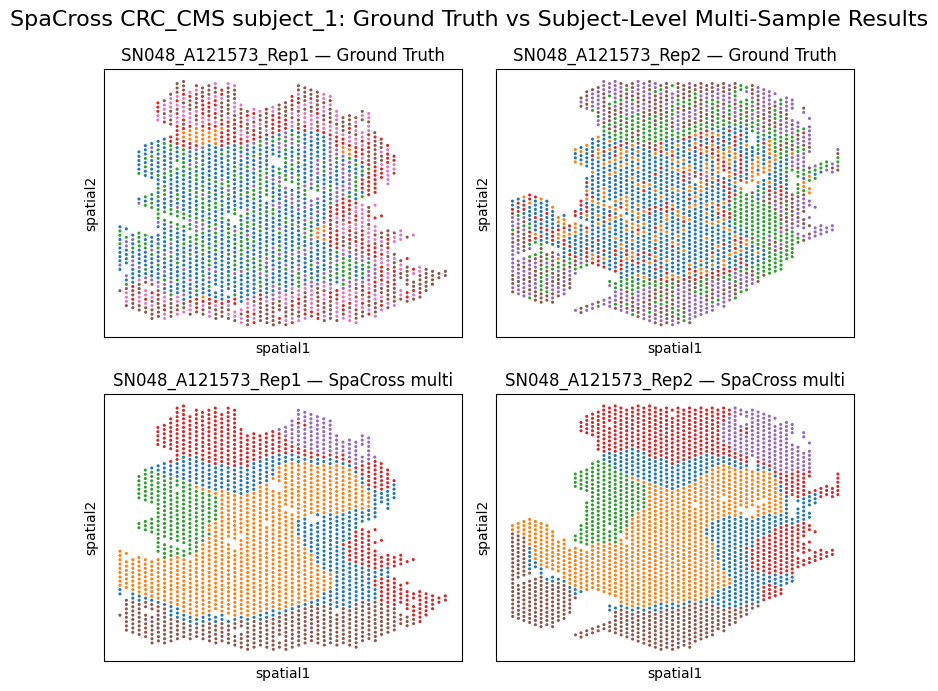

In [8]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path

DATA_ROOT  = Path(r"/groups/qiwei/mocha/QuickSRT/CRC_CMS_10x/data")
OUTPUT_DIR = Path(r"/home/dal875013/work/projects/mocha/results/Spacross/crc_cms_spacross_MULTI")

SUBJECT_TO_PLOT = "subject_1"
SAMPLES_TO_PLOT = {
    "subject_1": ["SN048_A121573_Rep1", "SN048_A121573_Rep2"],
    "subject_2": ["SN048_A416371_Rep1", "SN048_A416371_Rep2"],
    "subject_3": ["SN123_A551763_Rep1", "SN124_A551763_Rep2"],
    "subject_4": ["SN123_A595688_Rep1", "SN124_A595688_Rep2"],
    "subject_5": ["SN123_A798015_Rep1", "SN124_A798015_Rep2"],
    "subject_6": ["SN123_A938797_Rep1_X", "SN124_A938797_Rep2"],
    "subject_7": ["SN84_A120838_Rep1", "SN84_A120838_Rep2"],
}[SUBJECT_TO_PLOT]

predictions = pd.read_parquet(OUTPUT_DIR / "predictions.parquet")

fig, axes = plt.subplots(2, len(SAMPLES_TO_PLOT), figsize=(4 * len(SAMPLES_TO_PLOT), 7))
fig.suptitle(f"SpaCross CRC_CMS {SUBJECT_TO_PLOT}: Ground Truth vs Subject-Level Multi-Sample Results", fontsize=16)

# Make axes 2D even when there is only one sample.
axes = np.asarray(axes)
if axes.ndim == 1:
    axes = axes.reshape(2, -1)

for j, sample_id in enumerate(SAMPLES_TO_PLOT):
    pred_slice = predictions[predictions["sample"].astype(str) == str(sample_id)].set_index("spot_id")

    if pred_slice.empty:
        axes[0, j].set_title(f"{sample_id} missing")
        axes[1, j].set_title(f"{sample_id} missing")
        continue

    adata = sc.read_h5ad(DATA_ROOT / f"SCE_{sample_id}.h5ad")
    adata.var_names_make_unique()

    adata.obs["true_label"] = pred_slice["true_label"].reindex(adata.obs_names.astype(str)).values
    adata.obs["pred_label"] = pred_slice["pred_label"].reindex(adata.obs_names.astype(str)).values

    if "spatial" not in adata.obsm and "S" in adata.obsm:
        adata.obsm["spatial"] = np.asarray(adata.obsm["S"])
    elif "spatial" in adata.obsm:
        adata.obsm["spatial"] = np.asarray(adata.obsm["spatial"])
    else:
        raise KeyError(f"No spatial coordinates found for {sample_id}. obsm keys={list(adata.obsm.keys())}")

    sc.pl.embedding(
        adata, basis="spatial", color="true_label",
        ax=axes[0, j], show=False, title=f"{sample_id} — Ground Truth", s=20,
        legend_loc=None,
    )
    sc.pl.embedding(
        adata, basis="spatial", color="pred_label",
        ax=axes[1, j], show=False, title=f"{sample_id} — SpaCross multi", s=20,
        legend_loc=None,
    )
    axes[0, j].invert_yaxis()
    axes[1, j].invert_yaxis()

plt.tight_layout()
plt.show()


# Running results summary


In [9]:
import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path(r"/home/dal875013/work/projects/mocha/results/Spacross/crc_cms_spacross_MULTI")
perf_path = OUTPUT_DIR / "performance.parquet"

if not perf_path.exists():
    raise FileNotFoundError(f"Cannot find {perf_path}")

performance = pd.read_parquet(perf_path)
performance = performance.sort_values(["training_unit", "sample", "run_seed"]).reset_index(drop=True)

display_cols = [
    "training_unit", "sample", "run_seed",
    "ARI", "NMI", "ACC", "DIS", "HOM", "COM", "V_measure",
    "num_clusters", "num_spots", "num_labeled_spots",
    "num_training_spots", "num_genes_after_hvg",
    "pca_dim", "latent_dim", "k_cutoff", "topk_neighs", "topk_neighs_inter",
    "running_time_sec", "subject_running_time_sec",
    "gpu_model",
]
display_cols = [c for c in display_cols if c in performance.columns]

print("===== All SpaCross subject-level CRC_CMS results =====")
display(performance[display_cols])

print("\n===== Summary =====")
metric_cols = [c for c in ["ARI", "NMI", "ACC", "DIS", "HOM", "COM", "V_measure", "running_time_sec"] if c in performance.columns]
display(performance[metric_cols].describe())

print("\n===== Mean metrics =====")
for col in ["ARI", "NMI", "ACC", "HOM", "COM", "V_measure"]:
    if col in performance.columns:
        print(f"Mean {col}: {performance[col].mean():.4f}")

print("\n===== Subject-level runtime =====")
runtime = performance[["training_unit", "run_seed", "subject_running_time_sec"]].drop_duplicates()
display(runtime)
print(f"Total subject-level runtime: {runtime['subject_running_time_sec'].sum():.2f} sec")

print("\n===== Best / worst ARI =====")
if "ARI" in performance.columns and len(performance) > 0:
    best = performance.loc[performance["ARI"].idxmax()]
    worst = performance.loc[performance["ARI"].idxmin()]
    print(f"Best ARI : {best['sample']} ({best['training_unit']})  ARI={best['ARI']:.4f}")
    print(f"Worst ARI: {worst['sample']} ({worst['training_unit']})  ARI={worst['ARI']:.4f}")




===== All SpaCross subject-level CRC_CMS results =====


,training_unit,sample,run_seed,ARI,NMI,ACC,DIS,HOM,COM,V_measure,...,num_training_spots,num_genes_after_hvg,pca_dim,latent_dim,k_cutoff,topk_neighs,topk_neighs_inter,running_time_sec,subject_running_time_sec,gpu_model
0,subject_1,SN048_A121573_Rep1,0,0.235819,0.321650,0.404483,NaN,0.310649,0.333459,0.321650,...,4343,2000,200,16,12,20,30,6.62,13.24,NVIDIA A30
1,subject_1,SN048_A121573_Rep2,0,0.242955,0.315606,0.415976,NaN,0.312035,0.319258,0.315606,...,4343,2000,200,16,12,20,30,6.62,13.24,NVIDIA A30
2,subject_2,SN048_A416371_Rep1,0,0.028675,0.083861,0.337937,NaN,0.090285,0.078290,0.083861,...,4120,2000,200,16,12,20,30,6.03,12.05,NVIDIA A30
3,subject_2,SN048_A416371_Rep2,0,0.023076,0.047356,0.359600,NaN,0.048909,0.045899,0.047356,...,4120,2000,200,16,12,20,30,6.03,12.05,NVIDIA A30
4,subject_3,SN123_A551763_Rep1,0,0.023511,0.051530,0.419549,NaN,0.057189,0.046891,0.051530,...,1830,2000,200,16,12,20,30,3.72,7.45,NVIDIA A30
5,subject_3,SN124_A551763_Rep2,0,0.008517,0.041526,0.278830,NaN,0.061884,0.031246,0.041526,...,1830,2000,200,16,12,20,30,3.72,7.45,NVIDIA A30
6,subject_4,SN123_A595688_Rep1,0,0.183540,0.316212,0.361836,NaN,0.294116,0.341898,0.316212,...,1467,2000,200,16,12,20,30,3.20,6.40,NVIDIA A30
7,subject_4,SN124_A595688_Rep2,0,0.123711,0.224059,0.407303,NaN,0.219848,0.228436,0.224059,...,1467,2000,200,16,12,20,30,3.20,6.40,NVIDIA A30
8,subject_5,SN123_A798015_Rep1,0,0.132888,0.248267,0.374767,NaN,0.232318,0.266566,0.248267,...,3209,2000,200,16,12,20,30,5.64,11.27,NVIDIA A30
9,subject_5,SN124_A798015_Rep2,0,0.146863,0.271371,0.358593,NaN,0.248042,0.299543,0.271371,...,3209,2000,200,16,12,20,30,5.64,11.27,NVIDIA A30



===== Summary =====


,ARI,NMI,ACC,DIS,HOM,COM,V_measure,running_time_sec
count,14.000000,14.000000,14.000000,0.0,14.000000,14.000000,14.000000,14.000000
mean,0.119486,0.201396,0.371238,NaN,0.195007,0.209887,0.201396,4.670000
std,0.075371,0.103197,0.039254,NaN,0.094005,0.112323,0.103197,1.517964
min,0.008517,0.041526,0.278830,NaN,0.048909,0.031246,0.041526,2.400000
25%,0.049768,0.113071,0.354302,NaN,0.113956,0.113558,0.113071,3.330000
50%,0.133116,0.222214,0.364083,NaN,0.217398,0.227252,0.222214,5.080000
75%,0.145100,0.269941,0.406598,NaN,0.253396,0.293911,0.269941,5.932500
max,0.242955,0.321650,0.419549,NaN,0.312035,0.341898,0.321650,6.620000



===== Mean metrics =====
Mean ARI: 0.1195
Mean NMI: 0.2014
Mean ACC: 0.3712
Mean HOM: 0.1950
Mean COM: 0.2099
Mean V_measure: 0.2014

===== Subject-level runtime =====


,training_unit,run_seed,subject_running_time_sec
0,subject_1,0,13.24
2,subject_2,0,12.05
4,subject_3,0,7.45
6,subject_4,0,6.40
8,subject_5,0,11.27
10,subject_6,0,10.16
12,subject_7,0,4.80


Total subject-level runtime: 65.37 sec

===== Best / worst ARI =====
Best ARI : SN048_A121573_Rep2 (subject_1)  ARI=0.2430
Worst ARI: SN124_A551763_Rep2 (subject_3)  ARI=0.0085
